<a href="https://colab.research.google.com/github/nevita275/ML_20_Nevita/blob/main/JS05/JS05-Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUGAS 1
## Siapkan Data dan Import Library

In [1]:
from google.colab import files
uploaded = files.upload()

Saving voice.csv to voice.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load data
df = pd.read_csv('voice.csv')
print(df.shape)
print(df['label'].value_counts())
print(df.isnull().sum().sum(), 'missing value')

# Pisahkan fitur dan label (male = 1, female = 0)
X = df.drop('label', axis=1)
y = df['label'].map({'male': 1, 'female': 0})

# Split data 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fungsi pembuat model: scaling + kNN dalam satu pipeline
mk = lambda k=5: Pipeline([('s', StandardScaler()),
                           ('knn', KNeighborsClassifier(n_neighbors=k))])

(3168, 21)
label
male      1584
female    1584
Name: count, dtype: int64
0 missing value


## 1. Buatlah model klasifikasi dengan menggunakan kNN untuk mengklasifikasikan jenis suara male dan female pada dataset voice.csv.

### 1a. Baca Data

In [8]:
print(df.shape)
print(df['label'].value_counts())
print(df.isnull().sum().sum(), 'missing value')
df.head()

(3168, 21)
label
male      1584
female    1584
Name: count, dtype: int64
0 missing value


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


### 1b. memisahkan fitur dan label, lalu encode

In [9]:
X = df.drop('label', axis=1)
y = df['label'].map({'male': 1, 'female': 0})

### 1c. Split data training dan testing

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(2534, 20) (634, 20)


### 1d. Buat pipeline scaling + kNN

In [11]:
mk = lambda k=5: Pipeline([('s', StandardScaler()),
                           ('knn', KNeighborsClassifier(n_neighbors=k))])

### 1e.Training dan evaluasi baseline (semua fitur, k=5)

In [12]:
base = mk(5).fit(X_train, y_train)
pred = base.predict(X_test)

print('Akurasi baseline (20 fitur, k=5):', accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, target_names=['female', 'male']))

Akurasi baseline (20 fitur, k=5): 0.9763406940063092
[[306  11]
 [  4 313]]
              precision    recall  f1-score   support

      female       0.99      0.97      0.98       317
        male       0.97      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



## 2. Lakukan percobaan untuk mengetahui fitur-fitur yang paling optimal untuk digunakan. Fitur apa saja yang Anda gunakan untuk mendapatkan hasil terbaik?

### 2a. Lihat korelasi fitur dengan label

In [13]:
corr = pd.concat([X_train, y_train], axis=1).corr()['label'].drop('label')
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
print(corr)

meanfun    -0.832070
IQR         0.618232
Q25        -0.510064
sp.ent      0.488622
sd          0.478224
sfm         0.359250
centroid   -0.337018
meanfreq   -0.337018
median     -0.281720
mindom     -0.195303
maxdom     -0.191644
dfrange    -0.188264
meandom    -0.184510
mode       -0.170793
maxfun     -0.163647
minfun     -0.135519
kurt        0.087038
Q75         0.066675
skew        0.038777
modindx     0.028871
Name: label, dtype: float64


### 2b. Lihat korelasi antar fitur

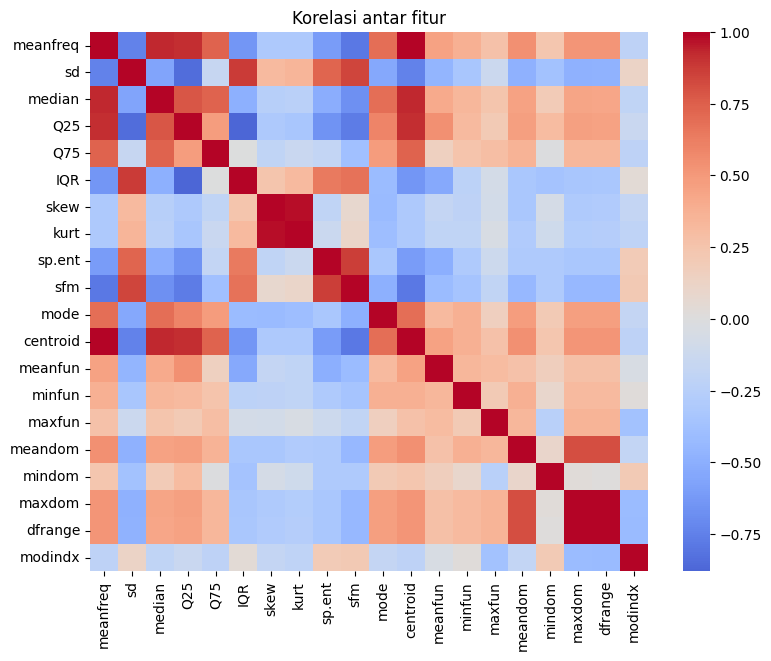

In [14]:
plt.figure(figsize=(9, 7))
sns.heatmap(X_train.corr(), cmap='coolwarm', center=0)
plt.title('Korelasi antar fitur')
plt.show()

### 2c. Ranking dengan mutual information

In [15]:
from sklearn.feature_selection import mutual_info_classif

mi = pd.Series(mutual_info_classif(X_train, y_train, random_state=42),
               index=X_train.columns).sort_values(ascending=False)

hasil_mi = []
for n in range(1, 21):
    f = mi.index[:n].tolist()
    hasil_mi.append((n, cross_val_score(mk(), X_train[f], y_train, cv=5).mean()))
hasil_mi = pd.DataFrame(hasil_mi, columns=['n', 'cv'])
print(hasil_mi.loc[hasil_mi['cv'].idxmax()])

n     9.000000
cv    0.977511
Name: 8, dtype: float64


### 2d. Forward Selection

In [16]:
res, sets = [], {}
for n in range(2, 13):
    sfs = SequentialFeatureSelector(mk(), n_features_to_select=n,
                                    direction='forward', cv=5, n_jobs=-1).fit(X_train, y_train)
    f = X_train.columns[sfs.get_support()].tolist()
    sets[n] = f
    res.append((n, cross_val_score(mk(), X_train[f], y_train, cv=5).mean()))

res = pd.DataFrame(res, columns=['n', 'cv'])
print(res)

     n        cv
0    2  0.968828
1    3  0.975535
2    4  0.977114
3    5  0.978694
4    6  0.980271
5    7  0.979878
6    8  0.980667
7    9  0.980665
8   10  0.980270
9   11  0.978693
10  12  0.977901


### 2e. Pilih jumlah fitur terbaik dan buat grafik

Jumlah fitur terbaik: 8
Fitur terbaik: ['meanfreq', 'sd', 'median', 'Q25', 'IQR', 'sfm', 'meanfun', 'maxfun']


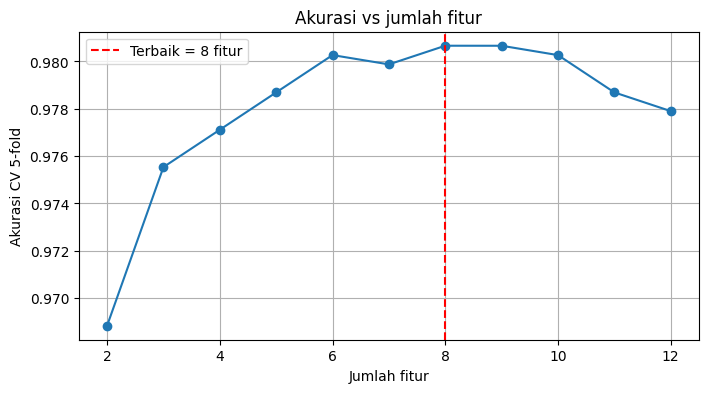

In [17]:
nb = int(res.loc[res['cv'].idxmax(), 'n'])
fitur_terpilih = sets[nb]
print('Jumlah fitur terbaik:', nb)
print('Fitur terbaik:', fitur_terpilih)

plt.figure(figsize=(8, 4))
plt.plot(res['n'], res['cv'], marker='o')
plt.axvline(nb, color='r', linestyle='--', label=f'Terbaik = {nb} fitur')
plt.xlabel('Jumlah fitur'); plt.ylabel('Akurasi CV 5-fold')
plt.title('Akurasi vs jumlah fitur'); plt.legend(); plt.grid(True)
plt.show()

## 3. Berdasarkan fitur yang telah Anda pilih pada soal nomor 2, berapa nilai  k yang terbaik? Lampirkan grafika analisis dan alasan Anda.

### 3a. Menentukan rentang k, hitung akurasi training dan CV untuk tiap k



In [18]:
# Tentukan rentang k, lalu hitung akurasi training dan CV untuk tiap k
ks = range(1, 31)
cv, tr = [], []

for k in ks:
    cv.append(cross_val_score(mk(k), X_train[fitur_terpilih], y_train, cv=5).mean())
    tr.append(mk(k).fit(X_train[fitur_terpilih], y_train).score(X_train[fitur_terpilih], y_train))

### 3b. Menentukan k terbaik

In [19]:
best_k = list(ks)[int(np.argmax(cv))]
print('k terbaik:', best_k, '| Akurasi CV:', max(cv))

k terbaik: 6 | Akurasi CV: 0.9810611907601874


### 3c. Membuat grafik analisis

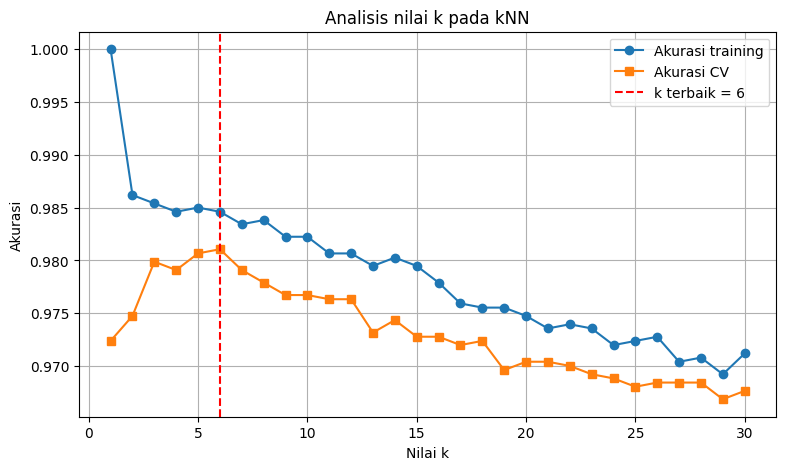

In [20]:
plt.figure(figsize=(9, 5))
plt.plot(ks, tr, marker='o', label='Akurasi training')
plt.plot(ks, cv, marker='s', label='Akurasi CV')
plt.axvline(best_k, color='r', linestyle='--', label=f'k terbaik = {best_k}')
plt.xlabel('Nilai k'); plt.ylabel('Akurasi')
plt.title('Analisis nilai k pada kNN')
plt.legend(); plt.grid(True)
plt.show()

### Analisis grafik:
* k terlalu kecil (k=1): akurasi training 100% tetapi akurasi CV hanya sekitar 0,972. Model menghafal data training, ini adalah overfitting.
* k terlalu besar (k > 10): kedua kurva terus turun sampai sekitar 0,97 di k=30. Model terlalu halus dan mengabaikan pola lokal, ini adalah underfitting.
* k = 6: akurasi CV tertinggi dan selisih training-CV kecil, jadi keseimbangan terbaik antara bias dan variansi.

### 3d. Evaluasi akhir di data testing

In [21]:
final = mk(best_k).fit(X_train[fitur_terpilih], y_train)
pred = final.predict(X_test[fitur_terpilih])

print('Akurasi test:', accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, target_names=['female', 'male']))

Akurasi test: 0.9873817034700315
[[313   4]
 [  4 313]]
              precision    recall  f1-score   support

      female       0.99      0.99      0.99       317
        male       0.99      0.99      0.99       317

    accuracy                           0.99       634
   macro avg       0.99      0.99      0.99       634
weighted avg       0.99      0.99      0.99       634

